In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('hotel_data_modified.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03


is_canceled --> 0 / 1

- Customers with babies or children may have higher cancellation probability  
- Longer lead time may increase cancellation likelihood  
- Repeated guests may have lower cancellation probability  
- Higher previous cancellations may indicate higher future cancellation risk  
- Longer waiting list days may increase cancellation likelihood  

* What if free room upgrades are offered?  
* If full/half meal plans reduce cancellation rates, consider offering them as paid options

In [3]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
agent                              16340
company                           112593
days_in_waiting_

In [4]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
agent                             float64
company                           

In [5]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

### 1) First Analysis

In [6]:
df['children'].unique()

array([ 0.,  1.,  2., 10.,  3., nan])

In [7]:
# Data Cleaning: Handling Missing Values and Converting Data Types (float to int)
df_kids = df.dropna(subset=['children']).copy()
df_kids['children'] = df_kids['children'].astype(int)

In [8]:
# Outlier Removal
df_kids = df_kids[df_kids['children'] <= 3]
df_kids

# Unrealistic values in the "kids" variable (e.g., 10 children) were removed.
# Only observations with 3 or fewer children were retained for analysis.

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,A,0,394.0,NaN,0,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,E,0,9.0,NaN,0,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,D,0,9.0,NaN,0,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,A,0,89.0,NaN,0,0,0,Check-Out,2017-09-07


In [9]:
df_kids['children'].value_counts().sort_index()

children
0    110796
1      4861
2      3652
3        76
Name: count, dtype: int64

In [10]:
# How Does the Number of Children Affect Cancellation Probability?
df_kids.groupby('children')['is_canceled'].mean()

children
0    0.370898
1    0.322362
2    0.421961
3    0.223684
Name: is_canceled, dtype: float64

In [11]:
import statsmodels.api as sm

X = df_kids[['children']]
X = sm.add_constant(X)
y = df_kids['is_canceled']

model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.659151
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:               119385
Model:                          Logit   Df Residuals:                   119383
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:               1.734e-05
Time:                        12:43:09   Log-Likelihood:                -78693.
converged:                       True   LL-Null:                       -78694.
Covariance Type:            nonrobust   LLR p-value:                   0.09855
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5331      0.006    -86.044      0.000      -0.545      -0.521
children       0.0248      0.015      1.655      0.098      -0.005       0.054
==============================================================================
"""

In [12]:
# coef = 0.0248
# p-value = 0.098

# The results suggest that the number of children is positively associated with cancellation probability.  
# However, this relationship is not statistically significant.

In [13]:
df_baby = df_kids.copy()
df_baby['babies'].value_counts().sort_index()

babies
0     118468
1        900
2         15
9          1
10         1
Name: count, dtype: int64

In [14]:
# Outlier Removal
df_baby = df_baby[df_baby['babies'] <= 2]
df_baby

# Unrealistic values in the "babies" variable (e.g., 9 or more babies) were removed. 
# Only observations with 2 or fewer babies were retained for analysis.

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,A,0,394.0,NaN,0,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,E,0,9.0,NaN,0,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,D,0,9.0,NaN,0,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,A,0,89.0,NaN,0,0,0,Check-Out,2017-09-07


In [15]:
df_baby['babies'].value_counts().sort_index()

babies
0    118468
1       900
2        15
Name: count, dtype: int64

In [16]:
# How Does the Number of Babies Affect Cancellation Probability?
df_baby.groupby('babies')['is_canceled'].mean()

babies
0    0.371847
1    0.183333
2    0.133333
Name: is_canceled, dtype: float64

In [17]:
import statsmodels.api as sm

X = df_baby[['babies']]
X = sm.add_constant(X)
y = df_baby['is_canceled']

model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.658517
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:               119383
Model:                          Logit   Df Residuals:                   119381
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:               0.0009856
Time:                        12:43:09   Log-Likelihood:                -78616.
converged:                       True   LL-Null:                       -78693.
Covariance Type:            nonrobust   LLR p-value:                 1.323e-35
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5243      0.006    -87.222      0.000      -0.536      -0.513
babies        -0.9578      0.085    -11.313      0.000      -1.124      -0.792
==============================================================================
"""

In [18]:
# coef = -0.9578
# p-value = 0

# The number of babies has a statistically significant effect on cancellation probability.  
# As the number of babies increases, the likelihood of cancellation decreases.

In [19]:
# babies + children
df_all = df_kids.copy()
df_all = df_all[df_all['babies'] <= 2]
df_all = df_all[df_all['children'] <= 3]

In [20]:
import statsmodels.api as sm

X = df_all[['children', 'babies']]
X = sm.add_constant(X)
y = df_all['is_canceled']

model_all = sm.Logit(y, X).fit()
model_all.summary()

Optimization terminated successfully.
         Current function value: 0.658500
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:               119383
Model:                          Logit   Df Residuals:                   119380
Method:                           MLE   Df Model:                            2
Date:                Sat, 02 May 2026   Pseudo R-squ.:                0.001010
Time:                        12:43:09   Log-Likelihood:                -78614.
converged:                       True   LL-Null:                       -78693.
Covariance Type:            nonrobust   LLR p-value:                 2.981e-35
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5274      0.006    -84.912      0.000      -0.540      -0.515
children       0.0296      0.015      1.974      0.048       0.000       0.059
babies        -0.9615      0.085    -11.352      0.000      -1.127      -0.795
==============================================================================
"""

In [21]:
# children coef = 0.0296, p-value = 0.048
# babies coef = -0.9615, p-value = 0.000

# Controlling for the number of babies, the number of children has a statistically significant effect on cancellation probability.  
# As the number of children increases, the likelihood of cancellation also increases.  
# Meanwhile, the number of babies remains a key factor that decreases cancellation probability.

In [22]:
df_seg = df_kids.copy()

def segment(row):
    if row['babies'] >= 1:
        return 'babies'
    elif row['children'] >= 1:
        return 'children_only'
    else:
        return 'no_kids'

df_seg['segment'] = df_seg.apply(segment, axis=1)

In [23]:
# Cancellation Rate by Segment
df_seg.groupby('segment')['is_canceled'].mean()

segment
babies           0.182116
children_only    0.367364
no_kids          0.372190
Name: is_canceled, dtype: float64

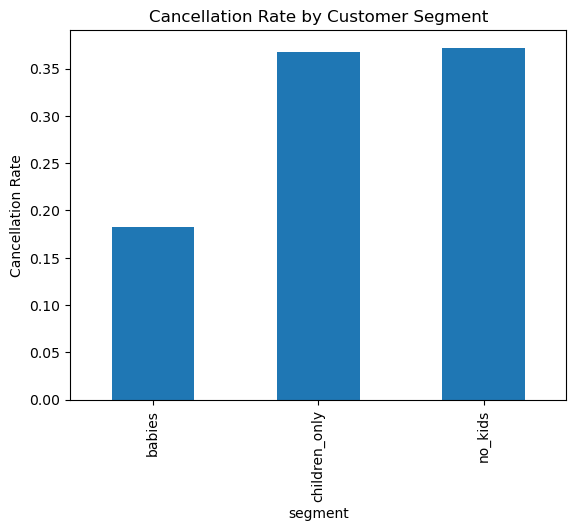

In [24]:
import matplotlib.pyplot as plt

df_seg.groupby('segment')['is_canceled'].mean().plot(kind='bar')
plt.title('Cancellation Rate by Customer Segment')
plt.ylabel('Cancellation Rate')
plt.show()

## 1. Customer Segmentation

### 1) Customers with Babies (babies >= 1)
- Lower cancellation rate  
- More planned trips  

### 2) Customers with Children (children >= 1, no babies)
- Relatively higher cancellation rate  
- Higher schedule uncertainty  

### 3) General Customers (no kids)
- Average cancellation rate  
- Baseline group  

## 2. Marketing Strategy

### 1) Customers with Babies → Revenue Maximization Strategy
- Paid room upgrades  
- Meal package upselling  
- Baby-friendly premium packages  

### 2) Customers with Children → Cancellation Prevention Strategy
- Shorten or restrict free cancellation period  
- Offer confirmed benefits instead of discounts (e.g., free breakfast if booking is maintained)  

### 3) General Customers
- Apply seasonal and demand-based pricing  
- General promotions (discounts, packages)  
- Encourage add-ons (breakfast, room upgrade)

### 2) Second Analysis

In [25]:
df['lead_time'].describe()

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

In [26]:
df['lead_group'] = pd.cut(df['lead_time'],
                         bins=[0, 30, 90, 180, 365, 800],
                         labels=['very_short', 'short', 'mid', 'long', 'very_long'])

In [27]:
df.groupby('lead_group', observed=False)['is_canceled'].mean()

lead_group
very_short    0.208739
short         0.376984
mid           0.447105
long          0.554540
very_long     0.676620
Name: is_canceled, dtype: float64

In [28]:
import statsmodels.api as sm

X = df[['lead_time']]
X = sm.add_constant(X)
y = df['is_canceled']

model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.616290
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:               119390
Model:                          Logit   Df Residuals:                   119388
Method:                           MLE   Df Model:                            1
Date:                Sat, 02 May 2026   Pseudo R-squ.:                 0.06506
Time:                        12:43:10   Log-Likelihood:                -73579.
converged:                       True   LL-Null:                       -78699.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1656      0.009   -126.940      0.000      -1.184      -1.148
lead_time      0.0059   6.14e-05     95.404      0.000       0.006       0.006
==============================================================================
"""

In [29]:
# coef = 0.0059
# p-value = 0

# Lead time has a statistically significant positive effect on cancellation probability.  
# As lead time increases, the likelihood of cancellation also increases.

## Long Lead-Time Customers → Cancellation Prevention Strategy

### Strategy
- Send reminder messages before check-in  
- Offer incentives for maintaining reservations (e.g., free breakfast)  
- Adjust partial refund policies  

**Encouraging customers to reconsider before canceling is important.**

## 3) Third Analysis

In [30]:
df['is_repeated_guest'].value_counts()

is_repeated_guest
0    115580
1      3810
Name: count, dtype: int64

In [31]:
df.groupby('is_repeated_guest')['is_canceled'].mean()

is_repeated_guest
0    0.377851
1    0.144882
Name: is_canceled, dtype: float64

## 1. Customer Segmentation

### 1) Returning Customers (1)
- Lower cancellation rate  
- High customer loyalty  

### 2) New Customers (0)
- Higher cancellation rate  

## 2. Marketing Strategy

### 1) Retention and Loyalty Building
- VIP / membership programs  
- Reward points  
- Personalized benefits  

### 2) Optimizing First-Time Experience
- Encourage confirmed bookings through incentives  
- Emphasize reviews and trust signals  
- Offer first-time customer discounts  

## 4) Fourth Analysis

In [32]:
df['previous_cancellations'].value_counts().sort_index()

previous_cancellations
0     112906
1       6051
2        116
3         65
4         31
5         19
6         22
11        35
13        12
14        14
19        19
21         1
24        48
25        25
26        26
Name: count, dtype: int64

In [33]:
def cancel_group(x):
    if x == 0:
        return '0'
    elif x == 1:
        return '1'
    else:
        return '2+'

df['cancel_group'] = df['previous_cancellations'].apply(cancel_group)

In [34]:
df.groupby('cancel_group')['is_canceled'].mean()

cancel_group
0     0.339061
1     0.944307
2+    0.526559
Name: is_canceled, dtype: float64

Customers with previous cancellation history show a significantly higher likelihood of canceling.  
Notably, even customers with a single prior cancellation exhibit high cancellation rates.  

- Apply prepayment or stricter cancellation policies to customers with prior cancellations  
- Treat customers without cancellation history as general customers and apply standard promotions  

**Note: The small sample size of customers with two or more prior cancellations may lead to variability in the results.**

## 5) Fifth Analysis

In [35]:
df['days_in_waiting_list'].value_counts().sort_index()

days_in_waiting_list
0      115692
1          12
2           5
3          59
4          25
        ...  
236        35
259        10
330        15
379        15
391        45
Name: count, Length: 128, dtype: int64

In [36]:
df['waiting_group'] = df['days_in_waiting_list'].apply(lambda x: '0' if x == 0 else '1+')

In [37]:
df.groupby('waiting_group')['is_canceled'].mean()

waiting_group
0     0.361866
1+    0.637912
Name: is_canceled, dtype: float64

### Customers on the Waiting List (1+)
- Encourage faster booking confirmation  
- Provide incentives during the waiting period (e.g., discounts, upgrade offers)  
- Send continuous reminder messages  

**It is important to retain customers during the waiting period and prevent drop-off.**

## Evaluating the Effectiveness of Marketing Strategies

In [38]:
df.groupby('meal')['is_canceled'].mean()

meal
BB           0.373849
FB           0.598997
HB           0.344603
SC           0.372394
Undefined    0.244654
Name: is_canceled, dtype: float64

Moderately priced meal-inclusive packages reduce customer burden and increase booking confirmation rates.  
In contrast, full board packages show relatively higher cancellation rates.  

This may be due to higher cost 부담 or characteristics of customers who choose such packages.  
Therefore, to improve booking retention, it is important to design offerings centered around reasonably priced service bundles.


For full board packages, additional conditions or incentives may be needed to increase booking confirmation.

In [39]:
df['is_upgraded'] = (df['assigned_room_type'] != df['reserved_room_type']).astype(int)
df.groupby('is_upgraded')['is_canceled'].mean()

is_upgraded
0    0.415629
1    0.053764
Name: is_canceled, dtype: float64

Analysis based on room upgrade status shows that customers who received upgrades had a very low cancellation rate of approximately 5%, while those who did not receive upgrades showed a significantly higher cancellation rate of about 41%.  

- Offer upgrade benefits to customers with a high risk of cancellation  
- Promote the possibility of upgrades in advance to encourage booking retention  
- Provide paid upgrade options for low-risk customers  

In [40]:
import statsmodels.api as sm

# Select only the variables needed for analysis
df_model = df[['is_canceled',
               'lead_time',
               'is_repeated_guest',
               'previous_cancellations',
               'children',
               'babies',
               'days_in_waiting_list']].copy()

# Create waiting variable
df_model['waiting'] = (df_model['days_in_waiting_list'] > 0).astype(int)

# Remove missing values
df_model = df_model.dropna()

# Define X and y
X = df_model[['lead_time',
              'is_repeated_guest',
              'previous_cancellations',
              'children',
              'babies',
              'waiting']]

y = df_model['is_canceled']

# Add constant term (intercept)
X = sm.add_constant(X)

# Logistic regression
model = sm.Logit(y, X).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.592398
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:               119386
Model:                          Logit   Df Residuals:                   119379
Method:                           MLE   Df Model:                            6
Date:                Sat, 02 May 2026   Pseudo R-squ.:                  0.1013
Time:                        12:43:11   Log-Likelihood:                -70724.
converged:                       True   LL-Null:                       -78695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.1561      0.010   -119.874      0.000      -1.175      -1.137
lead_time                  0.0049   6.33e-05     78.189      0.000       0.005       0.005
is_repeated_guest         -2.1728      0.067    -32.353      0.000      -2.304      -2.041
previous_cancellations     2.0906      0.039     53.350      0.000       2.014       2.167
children                   0.1353      0.015      8.772      0.000       0.105       0.166
babies                    -0.8159      0.087     -9.421      0.000      -0.986      -0.646
waiting                    0.5159      0.038     13.687      0.000       0.442       0.590
==========================================================================================
"""

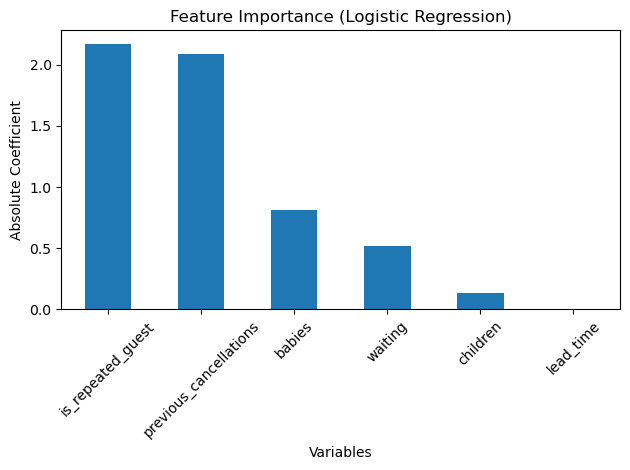

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients
coef = model.params

# Remove intercept
coef = coef.drop('const')

# Calculate importance based on absolute values
importance = coef.abs().sort_values(ascending=False)

# Visualization
plt.figure()
importance.plot(kind='bar')

plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Variables')
plt.ylabel('Absolute Coefficient')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df_model[['lead_time','is_repeated_guest','previous_cancellations','children','babies','waiting']]
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
accuracy_score(y_test, pred)

0.6888349107965491

In [43]:
from sklearn.metrics import roc_auc_score
proba = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, proba)

0.7071621334932683

In [44]:
result = pd.DataFrame({
    'actual': y_test,
    'prob': proba
})

result.sort_values('prob', ascending=False).head(20)

,actual,prob
14836,1,1.0
14846,1,1.0
14835,1,1.0
14800,1,1.0
14845,1,1.0
14985,1,1.0
14999,1,1.0
14995,1,1.0
15173,1,1.0
14779,1,1.0


In [45]:
high_risk = result[result['prob'] >= 0.7]
len(high_risk) / len(result)

0.06533210486640423

In [46]:
# 1. Overall Cancellation Rate
overall = result['actual'].mean()

# 2. High-Risk Cancellation Rate
high = high_risk['actual'].mean()

# 3. Comparison
overall, high

(0.36912639249518386, 0.8769230769230769)

## Conclusion

This analysis was conducted to reduce hotel booking cancellation rates.

First, key variables related to booking cancellations were identified through univariate analysis.  
Based on this, lead time, repeat customer status (is_repeated_guest), previous cancellations, number of children (children, babies), and waiting status were selected as key variables.

A multiple logistic regression analysis was then performed to compare the relative impact of these variables.  
The results showed that previous cancellations and repeat customer status were the most influential factors.

Based on these findings, a model was developed to predict cancellation probability for each customer.  
Using this model, approximately 6.7% of customers were identified as high-risk.  
The actual cancellation rate of this group was about 85.1%, which is more than twice the overall average cancellation rate (36.7%).

This indicates that the model effectively identifies customers with a high likelihood of cancellation.

Based on these results, applying proactive strategies to high-risk customers (with a predicted cancellation probability above 70%)—such as requiring prepayment, strengthening booking confirmation, and offering additional incentives—can effectively reduce cancellation rates.

For example, if even a portion of the 1,603 high-risk customers can be retained, approximately 300–400 cancellations could be prevented.  
This would lead to a meaningful reduction in the overall cancellation rate.

In addition, for customers with low cancellation risk, upselling and package offerings can be used to generate additional revenue.

However, this analysis is based on a limited set of variables and does not account for factors such as pricing, schedule changes, or external conditions.  
Future research incorporating these factors could further improve model performance.

Overall, this analysis not only identifies key drivers of booking cancellations but also demonstrates the potential for proactively identifying high-risk customers and implementing targeted strategies to reduce cancellations.